In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
from datetime import datetime
import yaml

In [4]:
control_key = "is_control"
condition_keys = "target_gene"
condition_rep_keys = "gene_embeddings"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data_origin = "ArcVirtualCell_42_0.1_False_X_pca_scaled"
sample_rep = "X_pca_scaled"

In [5]:
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 3656 × 18080
    obs: 'target_gene', 'guide_id', 'batch', 'is_control'
    var: 'gene_id'
    uns: 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_scaled'
    varm: 'PCs', 'X_mean'
    layers: 'X_centered'
AnnData object with n_obs × n_vars = 16623 × 18080
    obs: 'target_gene', 'guide_id', 'batch', 'is_control'
    var: 'gene_id'
    uns: 'log1p'
    obsm: 'X_pca', 'X_pca_scaled', 'gene_embeddings'
AnnData object with n_obs × n_vars = 1848 × 18080
    obs: 'target_gene', 'guide_id', 'batch', 'is_control'
    var: 'gene_id'
    uns: 'log1p'
    obsm: 'X_pca', 'X_pca_scaled', 'gene_embeddings'


## training

In [6]:
from src.training import pre_compute_wfr_ot, seed_everything
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

2026-02-07 23:33:57.369288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-07 23:33:57.417281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-07 23:33:57.431327: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-07 23:33:58.332139: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [7]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
ot_origin = f"delta{delta}_regm{reg_m}"
save_path_train = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_train.pkl"
save_path_test = f"./experiments/ot_plan/ot_precompute_{data_origin}_{ot_origin}_test.pkl"

load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


/home/pqw/project/DynamicVirtualCell/WFRFM/src/training/utils.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_indices = adata_treated.obs.groupby(condition_keys).indices
  0%|          | 0/10 [00:00<?, ?it/s]/home/pqw/anaconda3/envs/virtual_cell/lib/python3.10/site-packages/ot/backend.py:1560: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jax.device_put(jnp.array(1, dtype=jnp.float64), d),
100%|██████████| 10/10 [00:02<00:00,  3.34it/s]


Batch saved: 10/150


100%|██████████| 10/10 [00:01<00:00,  5.15it/s]


Batch saved: 20/150


100%|██████████| 10/10 [00:01<00:00,  5.19it/s]


...

Batch saved: 130/147


100%|██████████| 10/10 [00:01<00:00,  5.44it/s]


Batch saved: 140/147


100%|██████████| 7/7 [00:01<00:00,  5.00it/s]


Batch saved: 147/147
合并所有batch...
完成！最终结果: ./experiments/ot_plan/ot_precompute_ArcVirtualCell_42_0.1_False_X_pca_scaled_delta10_regm1_test.pkl


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

n_iterations = 30000

load_experiment = False # 如果是False可以无视下面三个参数
# experiment_load_path = "experiments/exp_20260128_213143_ArcVirtualCell_42_0.1_False_X_pca_scaled_delta10_regm1"
# config_load_path = os.path.join(experiment_load_path, "config.yaml")
# model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_epoch_10.pt") 

if not load_experiment:
    experiment_save_path = os.path.join("experiments", f"exp_{timestamp}_{data_origin}_{ot_origin}")
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")
    os.makedirs(checkpoint_save_path, exist_ok=True)
    
    config = {
        "in_out_dim": adata_control.obsm[sample_rep].shape[1],
        "condition_dim": adata_train.obsm[condition_rep_keys].shape[1],
        
        "hidden_dim_v": 4096,   
        "hidden_dim_g": 2048,
        "n_hiddens_v": 4,
        "n_hiddens_g": 2,
    
        "con_embedding_dim": 512,
        "hidden_dim_con": 1024,
        
        "time_dim": 1024,
        "time_embedding_dim": 256,
        "hidden_dim_time": 512,
        
        "bottle_dim": 1024,
        "activation": 'SiLU',
        
        "batch_size_per_condition": 256,  
        "batch_size_condition":10,
        "learning_rate": 5e-5,  
        "weight_decay":1e-4,
        "eta_min":5e-6,
        "seed": 42,
        "eval_interval":10,
    }
    config_save_path = f"{experiment_save_path}/config.yaml"
    with open(config_save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        print(f"config saved to {config_save_path}")
else:
    with open(config_load_path, 'r') as f:
        config = yaml.safe_load(f)
        print(f"load saved_config from {config_load_path}")

    experiment_save_path = experiment_load_path  #直接继续某一个实验
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")


model = FNet(config["in_out_dim"], config["hidden_dim_v"], config["n_hiddens_v"], config["hidden_dim_g"], config["n_hiddens_g"], 
             config["condition_dim"], config["con_embedding_dim"], config["hidden_dim_con"], 
             config["time_dim"] ,config["time_embedding_dim"],config["hidden_dim_time"], 
             config["bottle_dim"], config["activation"])
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=config["eta_min"])
seed_everything(config["seed"])

if load_experiment:    
    if os.path.exists(model_load_path):
        checkpoint = torch.load(model_load_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"load model from {model_load_path}")
    else:
        print("wrong model_load_path")

print("setup complete")

cuda
config saved to experiments/exp_20260207_233316_ArcVirtualCell_42_0.1_False_X_pca_scaled_delta10_regm1/config.yaml
Global seed set to 42
setup complete


In [10]:
n_iterations = 5000
model_save_path = os.path.join(checkpoint_save_path, "test")
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = config["batch_size_per_condition"],
                batch_size_condition = config["batch_size_condition"],
                sample_rep = sample_rep,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=model_save_path,
                eval_interval = config["eval_interval"],
                save_interval = 1000, #每隔多少轮保存一次
                save_only_last = True) # 是否只保留最后的pt文件


/home/pqw/project/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices
/home/pqw/project/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices


data_loaded
data_loaded


Begin flow and growth matching...: 100%|██████████| 5000/5000 [25:57<00:00,  3.21epoch/s, loss=0.025, vloss=0.023, gloss=0.002, test_loss=0.269, test_vloss=0.021, test_gloss=0.248]  


In [16]:
model_save_path

'experiments/exp_20260207_233316_ArcVirtualCell_42_0.1_False_X_pca_scaled_delta10_regm1/checkpoints/test'

训练步数: 4900
最后一步 Loss: 0.024999
最后一步 vLoss: 0.023302
最后一步 gLoss: 0.001696
最后一步 test_Loss: 0.268599
最后一步 test_vLoss: 0.020663
最后一步 test_gLoss: 0.247935


FileNotFoundError: [Errno 2] No such file or directory: '/home/pqw/project/DynamicVirtualCell/WFRFM/results/figures/loss_test_epoch_5000.png'

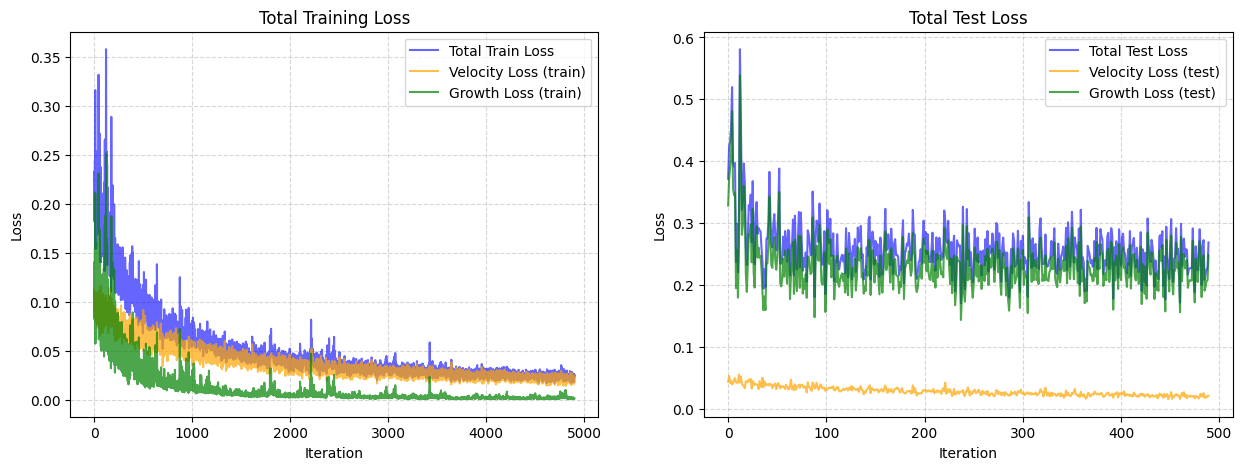

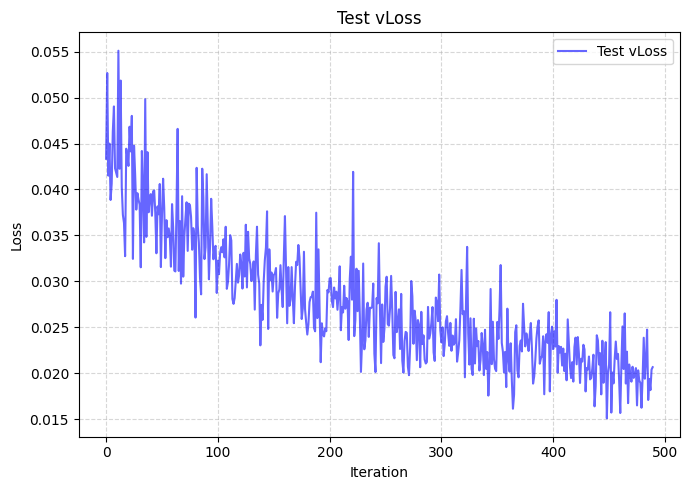

In [18]:
from src.evaluate import draw_loss
load_path = checkpoint_save_path + "/test_epoch_5000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100) # cut代表去掉前多少个epoch 避免前期loss过大影响观察